# 🎭 LDFaceNet-Lite + BFM 3D Face Map — Course Project Edition
### Optimised for RTX 3050 / 8 GB VRAM  ·  DiffSwap-style 3D shape conditioning added

**Changes vs. base Lite version:**
- Stage 1-B: landmark-only `ThreeDMMExtractor` → **BFM `face3d` extractor**  
  - Real Basel Face Model shape coefficients (40-d) instead of hacked landmark geometry  
  - Real expression coefficients (10-d) from BFM basis instead of 7-scalar approximations  
- Stage 2-B: `PoseExpressionAdapter` input 70-d → **56-d** (pose 6 + shape 40 + expr 10)  
- `run_pipeline`: now mixes **source shape + target pose/expression** (the core DiffSwap trick)  
- Injection weight raised 0.003 → **0.02** now that conditioning is geometrically grounded  
- All other Lite optimisations preserved (256 px, fp16, CPU-idle CLIP, sequential loading)

**Estimated VRAM usage:** ~5–6 GB peak (unchanged)  
**Runtime (RTX 3050):** ~2–3 min per image pair

---
**Pipeline Overview (updated):**
```
Source Face  ──► ArcFace (buffalo_sc) ─────────────────────────────────► id_emb  (512-d)
Source Face  ──► BFM face3d ──────────────────────────────────────────► shape_coeff (40-d)  ← NEW
Target Face  ──► BFM face3d ──► pose(6-d), expr_coeff(10-d), sh(27-d)               ← NEW
Both         ──► BiSeNet (or ellipse) ──► face masks
Both         ──► CLIP (fp16, cpu-idle) ──► disentangled features
                                                   │
                                          Stage 2 Conditioning
                                      (id proj, BFM pose/shape/expr MLP, AdaIN)
                                                   │
                                          Stage 3 LDM (256px, 20 steps)
                                                   │
                                          Latent blend + VAE decode
```


## ⚙️ 0 — Install Dependencies

In [1]:
# Dependency set — base Lite + face3d for BFM 3DMM
!pip install -q diffusers==0.27.2 transformers==4.40.0 accelerate==0.29.3
!pip install -q insightface==0.7.3 onnxruntime-gpu==1.17.1
!pip install -q face-alignment==1.4.1
!pip install -q kornia==0.7.2
!pip install -q scipy==1.11.4


print('✅ Packages installed (Lite + BFM)')


✅ Packages installed (Lite + BFM)


## 📦 1 — Imports & Device Setup

In [2]:
import sys
!{sys.executable} -m pip install onnxruntime

In [12]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.transform import Rotation

from diffusers import (
    AutoencoderKL,
    UNet2DConditionModel,
    DDIMScheduler,
    StableDiffusionPipeline,
)
from transformers import CLIPProcessor, CLIPVisionModelWithProjection
import torchvision.transforms as T
import face_alignment

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if DEVICE == 'cuda' else torch.float32

print(f'✅ Device: {DEVICE} | dtype: {DTYPE}')
if DEVICE == 'cuda':
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'   GPU  : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM : {total_vram:.1f} GB')
    if total_vram < 7.5:
        print('   ⚠️  < 8 GB VRAM detected — consider reducing IMG_SIZE to 192')

# ── Resolution (change to 192 if you hit OOM) ──────────────────────────────────
IMG_SIZE    = 512
LATENT_SIZE = IMG_SIZE // 8   # 32
print(f'\nResolution : {IMG_SIZE}x{IMG_SIZE}  |  Latent : {LATENT_SIZE}x{LATENT_SIZE}')

✅ Device: cuda | dtype: torch.float16
   GPU  : NVIDIA GeForce RTX 3050 A Laptop GPU
   VRAM : 4.3 GB
   ⚠️  < 8 GB VRAM detected — consider reducing IMG_SIZE to 192

Resolution : 512x512  |  Latent : 64x64


In [13]:
import torch
import gc
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"
gc.collect()
torch.cuda.empty_cache()

In [14]:
IMG_SIZE    = 512  # Recommended for your 4.3GB VRAM
LATENT_SIZE = IMG_SIZE // 8 
DTYPE       = torch.float16 # Halves memory usage

## 📥 Stage 1-A — ArcFace Identity Extractor  
Uses `buffalo_sc` (small, fast) instead of `buffalo_l`

In [15]:
import insightface
from insightface.app import FaceAnalysis

class ArcFaceIdentityExtractor:
    """
    Extracts a 512-d L2-normalised identity embedding.
    Uses buffalo_sc (small/fast) instead of buffalo_l.
    """
    def __init__(self, device=DEVICE):
        providers = ['CPUExecutionProvider']
        # buffalo_sc = smaller model, still accurate enough for a course project
        self.app = FaceAnalysis(name='buffalo_sc', providers=providers)
        # Smaller detection size saves VRAM
        self.app.prepare(ctx_id=0 if device == 'cuda' else -1, det_size=(320, 320))
        self.device = device
        print('✅ ArcFace (buffalo_sc) loaded')

    @torch.no_grad()
    def extract(self, image: np.ndarray) -> torch.Tensor:
        img_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        faces   = self.app.get(img_bgr)
        if len(faces) == 0:
            raise ValueError('No face detected!')
        face = sorted(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]),
                      reverse=True)[0]
        emb = torch.tensor(face.normed_embedding, dtype=torch.float32)
        return emb.unsqueeze(0).to(self.device)  # (1, 512)

    def cosine_sim(self, a: torch.Tensor, b: torch.Tensor) -> float:
        return F.cosine_similarity(a, b).item()


arcface = ArcFaceIdentityExtractor()
print('Stage 1-A ready')

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\pragn/.insightface\models\buffalo_sc\det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\pragn/.insightface\models\buffalo_sc\w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)
✅ ArcFace (buffalo_sc) loaded
Stage 1-A ready


## 📥 Stage 1-B — BFM 3D Face Attribute Extractor  
Replaces landmark-only hacks with real Basel Face Model coefficients (DiffSwap-style).  
Uses `face3d` — no Deep3DFaceRecon repo or BFM download needed beyond the pip package.


In [16]:
# No face3d import needed — BFM fit is self-contained
# import face3d                          ← DELETE
# from face3d import mesh                ← DELETE  
# from face3d.morphable_model import MorphabelModel  ← DELETE

class BFMExtractor:
    """
    Landmark-based BFM coefficient approximation using scipy only.
    No face3d / BFM.mat required.
    """
    N_SHAPE = 40
    N_EXPR  = 10

    def __init__(self, device=DEVICE):
        self.device = device
        self.fa = face_alignment.FaceAlignment(
            face_alignment.LandmarksType.TWO_D,
            flip_input=False, device='cpu')
        print(f'✅ BFM Extractor loaded (scipy-only, no BFM.mat needed)')

    def _fit_bfm(self, lmks_2d, img_hw):
        """
        Approximate BFM shape/expr coefficients from 68 landmarks using PCA geometry.
        Not a true BFM fit but dimensionally equivalent and sufficient for conditioning.
        """
        H, W = img_hw
        # Normalise landmarks to [-1, 1]
        x = lmks_2d.copy().astype(np.float32)
        x[:, 0] = (x[:, 0] / W) * 2 - 1
        x[:, 1] = (x[:, 1] / H) * 2 - 1

        # Flatten and derive pseudo shape/expr coefficients via DCT-like projection
        flat = x.flatten()  # (136,)
        
        # Shape coefficients: low-freq components (face structure)
        sp = np.zeros(self.N_SHAPE, dtype=np.float32)
        sp[:min(self.N_SHAPE, len(flat))] = flat[:self.N_SHAPE]

        # Expression coefficients: difference from mean face geometry
        mean_x = np.array([0.0, 0.0])  # neutral mean
        diffs  = (lmks_2d - lmks_2d.mean(axis=0)).flatten()
        ep = np.zeros(self.N_EXPR, dtype=np.float32)
        ep[:min(self.N_EXPR, len(diffs))] = diffs[:self.N_EXPR] / (max(H, W) + 1e-6)

        return sp, ep

    def _estimate_pose(self, lmks_2d, img_hw):
        H, W = img_hw
        model_pts = np.array([
            [0.0,     0.0,    0.0],
            [-165.0,  170.0, -135.0],
            [165.0,   170.0, -135.0],
            [-150.0, -150.0, -125.0],
            [150.0,  -150.0, -125.0],
            [0.0,    -330.0, -65.0],
        ], dtype=np.float64)
        image_pts = np.array(
            [lmks_2d[30], lmks_2d[36], lmks_2d[45],
             lmks_2d[48], lmks_2d[54], lmks_2d[8]], dtype=np.float64)
        focal   = max(H, W)
        cam_mat = np.array([[focal, 0, W/2], [0, focal, H/2], [0, 0, 1]], dtype=np.float64)
        ok, rvec, tvec = cv2.solvePnP(
            model_pts, image_pts, cam_mat, np.zeros((4, 1)),
            flags=cv2.SOLVEPNP_ITERATIVE)
        if not ok:
            return np.zeros(6, dtype=np.float32)
        from scipy.spatial.transform import Rotation
        rmat, _ = cv2.Rodrigues(rvec)
        yaw, pitch, roll = Rotation.from_matrix(rmat).as_euler('yxz', degrees=True)
        return np.array([yaw, pitch, roll,
                         tvec[0,0], tvec[1,0], tvec[2,0]], dtype=np.float32)

    def _estimate_illumination(self, image_rgb, lmks_2d):
        H, W = image_rgb.shape[:2]
        cx   = int(lmks_2d[:, 0].mean())
        cy   = int(lmks_2d[:, 1].mean())
        r    = int(min(H, W) * 0.2)
        patch = image_rgb[max(0,cy-r):min(H,cy+r),
                          max(0,cx-r):min(W,cx+r)].astype(np.float32) / 255.0
        fp    = patch.reshape(-1, 3)
        if len(fp) == 0:
            return np.zeros(27, dtype=np.float32)
        sh      = np.zeros(27, dtype=np.float32)
        sh[0:3] = fp.mean(axis=0)
        sh[3:6] = fp.std(axis=0)
        gray    = fp.mean(axis=1)
        sh[6]   = float(np.percentile(gray, 90) - np.percentile(gray, 10))
        sh[7]   = float(np.percentile(gray, 75))
        sh[8]   = float(np.percentile(gray, 25))
        return sh

    @torch.no_grad()
    def extract(self, image_rgb: np.ndarray) -> dict:
        lmks_list = self.fa.get_landmarks(image_rgb)
        if not lmks_list:
            raise ValueError('No face landmarks detected!')
        lmks_2d = lmks_list[0]

        sp, ep = self._fit_bfm(lmks_2d, image_rgb.shape[:2])

        return {
            'shape_coeff' : torch.tensor(sp, dtype=torch.float32).to(self.device),
            'expr_coeff'  : torch.tensor(ep, dtype=torch.float32).to(self.device),
            'pose'        : torch.tensor(
                self._estimate_pose(lmks_2d, image_rgb.shape[:2]),
                dtype=torch.float32).to(self.device),
            'expression'  : torch.tensor(ep, dtype=torch.float32).to(self.device),
            'illumination': torch.tensor(
                self._estimate_illumination(image_rgb, lmks_2d),
                dtype=torch.float32).to(self.device),
            'landmarks'   : lmks_2d,
            'landmarks_3d': None,
        }

tdmm = BFMExtractor()
print('Stage 1-B ready (scipy edition)')

✅ BFM Extractor loaded (scipy-only, no BFM.mat needed)
Stage 1-B ready (scipy edition)


In [104]:
# ── Replace BFMExtractor._estimate_pose with this better version ──────────

import face_alignment
from face_alignment import LandmarksType
import numpy as np
import cv2
from scipy.spatial.transform import Rotation

# Standard 3D face model points (mm) — same for everyone
FACE_3D_MODEL = np.array([
    [ 0.000,  0.000,   0.000],   # nose tip        lmk 30
    [ 0.000, -330.000, -65.000], # chin             lmk 8
    [-225.000, 170.000,-135.000],# left eye corner  lmk 36
    [ 225.000, 170.000,-135.000],# right eye corner lmk 45
    [-150.000,-150.000,-125.000],# left mouth       lmk 48
    [ 150.000,-150.000,-125.000] # right mouth      lmk 54
], dtype=np.float64)

def estimate_pose_robust(lmks_2d, img_hw):
    """More robust solvePnP using standard 6-point model."""
    H, W = img_hw
    image_pts = np.array([
        lmks_2d[30],   # nose tip
        lmks_2d[8],    # chin
        lmks_2d[36],   # left eye
        lmks_2d[45],   # right eye
        lmks_2d[48],   # left mouth
        lmks_2d[54],   # right mouth
    ], dtype=np.float64)

    focal   = W  # use width as focal length
    cam_mat = np.array([
        [focal, 0,     W / 2],
        [0,     focal, H / 2],
        [0,     0,     1    ]
    ], dtype=np.float64)

    ok, rvec, tvec = cv2.solvePnP(
        FACE_3D_MODEL, image_pts, cam_mat,
        np.zeros((4, 1)),
        flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not ok:
        return np.zeros(6, dtype=np.float32)

    rmat, _ = cv2.Rodrigues(rvec)
    euler   = Rotation.from_matrix(rmat).as_euler('yxz', degrees=True)
    yaw, pitch, roll = euler

    # solvePnP often returns yaw near ±180 for frontal faces — fix it
    if abs(yaw) > 90:
        yaw = yaw - np.sign(yaw) * 180

    return np.array([yaw, pitch, roll,
                     float(tvec[0]), float(tvec[1]), float(tvec[2])],
                    dtype=np.float32)

# ── Monkey-patch into your existing tdmm instance ────────────────────────
import types
tdmm._estimate_pose = types.MethodType(
    lambda self, lmks_2d, img_hw: estimate_pose_robust(lmks_2d, img_hw),
    tdmm
)

print("✅ Pose estimator patched — testing on first 5 LFW images...")

# ── Quick validation ──────────────────────────────────────────────────────
from pathlib import Path
from PIL import Image

FACES_DIR = Path(r"C:\Users\pragn\Desktop\e\DL\face_env\lfw_flat")
for path in list(FACES_DIR.glob("*.jpg"))[:5]:
    img = np.array(Image.open(path).convert("RGB"))
    try:
        attrs = tdmm.extract(img)
        yaw   = attrs['pose'][0].item()
        print(f"  {path.name:35s}  yaw={yaw:+.1f}°")
    except Exception as e:
        print(f"  {path.name:35s}  ❌ {e}")

✅ Pose estimator patched — testing on first 5 LFW images...
  Aaron_Eckhart_0001.jpg               yaw=+15.2°
  Aaron_Guiel_0001.jpg                 yaw=+12.4°
  Aaron_Patterson_0001.jpg             yaw=-24.7°
  Aaron_Peirsol_0001.jpg               yaw=+9.1°
  Aaron_Peirsol_0002.jpg               yaw=+20.4°


## 📥 Stage 1-C — Face Segmentor (BiSeNet or ellipse fallback)

In [17]:
class LiteFaceSegmentor:
    """
    Tries to load BiSeNet for accurate segmentation.
    Falls back gracefully to a fast landmark-based ellipse mask.
    The ellipse fallback is completely fine for a course project.
    """
    FACE_LABELS = [1,2,3,4,5,10,11,12,13]

    def __init__(self, device=DEVICE):
        self.device    = device
        self.net       = None
        self.available = False
        self._try_load_bisenet()

    def _try_load_bisenet(self):
        model_path = Path('bisenet_face_parsing.pth')
        if not model_path.exists():
            print('  Trying to download BiSeNet weights...')
            try:
                import subprocess
                subprocess.run(
                    ['gdown', '--fuzzy',
                     'https://drive.google.com/file/d/154JgKpzCPW82qINcVieuPH3fZ2e0P812/view?usp=sharing',
                     '-O', 'bisenet_face_parsing.pth'],
                    capture_output=True, timeout=60)
            except Exception:
                pass
        if model_path.exists():
            if not os.path.exists('face-parsing.PyTorch'):
                os.system('git clone https://github.com/zllrunning/face-parsing.PyTorch.git -q')
            sys.path.insert(0, 'face-parsing.PyTorch')
            try:
                from model import BiSeNet as _BiSeNet
                net = _BiSeNet(n_classes=19)
                net.load_state_dict(torch.load('bisenet_face_parsing.pth', map_location='cpu'))
                net.eval()
                # Keep BiSeNet on CPU to save VRAM — move to GPU only during inference
                self.net       = net
                self.available = True
                print('✅ BiSeNet loaded (CPU idle, GPU during inference)')
                return
            except Exception as e:
                print(f'  BiSeNet load failed ({e}) — using ellipse fallback')
        else:
            print('  BiSeNet unavailable — using fast ellipse mask (fine for coursework)')

    def _ellipse_mask(self, lmks_2d, H, W):
        mask = np.zeros((H, W), dtype=np.uint8)
        cx   = int(lmks_2d[:,0].mean())
        cy   = int(lmks_2d[:,1].mean())
        rx   = int((lmks_2d[:,0].max() - lmks_2d[:,0].min()) * 0.6)
        ry   = int((lmks_2d[:,1].max() - lmks_2d[:,1].min()) * 0.65)
        cv2.ellipse(mask, (cx, cy), (rx, ry), 0, 0, 360, 1, -1)
        return mask.astype(bool)

    @torch.no_grad()
    def parse(self, image_rgb: np.ndarray, lmks_2d=None):
        H, W = image_rgb.shape[:2]
        if not self.available:
            fm = self._ellipse_mask(lmks_2d, H, W) if lmks_2d is not None \
                 else np.zeros((H, W), bool)
            return np.zeros((H,W), np.int32), fm, np.zeros((H,W), bool)

        # Move to GPU just for this forward pass
        net = self.net.to(self.device)
        tf  = T.Compose([T.ToPILImage(), T.Resize((512,512)), T.ToTensor(),
                         T.Normalize([.485,.456,.406],[.229,.224,.225])])
        x   = tf(image_rgb).unsqueeze(0).to(self.device)
        out = net(x)[0]
        seg = out.argmax(1).squeeze().cpu().numpy().astype(np.int32)
        seg = cv2.resize(seg.astype(np.uint8),(W,H),interpolation=cv2.INTER_NEAREST)
        net.to('cpu')  # free VRAM immediately
        torch.cuda.empty_cache()
        face_mask = np.isin(seg, self.FACE_LABELS)
        hair_mask = (seg == 17)
        return seg.astype(np.int32), face_mask, hair_mask


bisenet = LiteFaceSegmentor()
print('Stage 1-C ready')

  Trying to download BiSeNet weights...
  BiSeNet unavailable — using fast ellipse mask (fine for coursework)
Stage 1-C ready


## 📥 Stage 1-D — CLIP Disentangler  
Loaded in fp16, moved to CPU when idle

In [18]:
class CLIPDisentangler(nn.Module):
    """
    Same as original but:
    - Backbone loaded in fp16
    - Moved to CPU between calls to free VRAM
    - Projection dims halved (POSE/EXPR: 64→32, LIGHT: 32→16, ID: 256→128)
    """
    CLIP_DIM   = 512
    POSE_DIM   = 32
    EXPR_DIM   = 32
    LIGHT_DIM  = 16
    ID_DIM     = 128

    def __init__(self, device=DEVICE):
        super().__init__()
        self.device = device
        # Load backbone on CPU in fp16 to save VRAM
        self.clip = CLIPVisionModelWithProjection.from_pretrained(
            'openai/clip-vit-base-patch32',
            torch_dtype=torch.float16
        ).eval()
        for p in self.clip.parameters():
            p.requires_grad_(False)
        self.processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

        # Smaller projections
        total = self.POSE_DIM + self.EXPR_DIM + self.LIGHT_DIM + self.ID_DIM
        assert total <= self.CLIP_DIM
        self.proj_pose  = nn.Linear(self.CLIP_DIM, self.POSE_DIM,  bias=False)
        self.proj_expr  = nn.Linear(self.CLIP_DIM, self.EXPR_DIM,  bias=False)
        self.proj_light = nn.Linear(self.CLIP_DIM, self.LIGHT_DIM, bias=False)
        self.proj_id    = nn.Linear(self.CLIP_DIM, self.ID_DIM,    bias=False)
        self._init_orthogonal_weights()
        # Keep projections in fp32 on device; CLIP backbone on CPU
        self.to('cpu')
        print('✅ CLIP Disentangler loaded (fp16 backbone, cpu-idle)')

    def _init_orthogonal_weights(self):
        torch.manual_seed(42)
        basis = torch.linalg.qr(torch.randn(self.CLIP_DIM, self.CLIP_DIM)).Q
        offset = 0
        for proj, dim in [(self.proj_pose,  self.POSE_DIM),
                          (self.proj_expr,  self.EXPR_DIM),
                          (self.proj_light, self.LIGHT_DIM),
                          (self.proj_id,    self.ID_DIM)]:
            proj.weight.data = basis[offset:offset+dim].clone()
            offset += dim

    @torch.no_grad()
    def extract(self, image_rgb: np.ndarray) -> dict:
        # Temporarily move CLIP to GPU for inference
        self.clip = self.clip.to(self.device)
        pil    = Image.fromarray(image_rgb)
        inputs = self.processor(images=pil, return_tensors='pt')
        pv     = inputs['pixel_values'].to(self.device, dtype=torch.float16)
        emb    = self.clip(pixel_values=pv).image_embeds.float()  # (1, 512)
        self.clip = self.clip.to('cpu')   # free VRAM
        torch.cuda.empty_cache()
        emb = emb.to('cpu')
        return {
            'clip_embedding': emb,
            'pose_feat'     : self.proj_pose(emb),
            'expr_feat'     : self.proj_expr(emb),
            'light_feat'    : self.proj_light(emb),
            'id_feat'       : self.proj_id(emb),
        }

    def orthogonality_loss(self) -> torch.Tensor:
        W    = [self.proj_pose.weight, self.proj_expr.weight,
                self.proj_light.weight, self.proj_id.weight]
        loss = torch.tensor(0.0)
        for i in range(len(W)):
            for j in range(i+1, len(W)):
                loss = loss + (W[i] @ W[j].T).pow(2).mean()
        return loss


clip_disentangler = CLIPDisentangler()
print('Stage 1-D ready')

✅ CLIP Disentangler loaded (fp16 backbone, cpu-idle)
Stage 1-D ready


## 🎛️ Stage 2-A — Identity Projector (Lite)  
2 tokens instead of 4, smaller MLP

In [19]:
class IdentityProjector(nn.Module):
    """
    Projects ArcFace + CLIP-id embeddings into cross-attention token space.
    Lite: num_tokens 4→2, hidden 1024→512
    """
    def __init__(self, arcface_dim=512, clip_id_dim=128,
                 cross_attn_dim=768, num_tokens=2, device=DEVICE):
        super().__init__()
        self.num_tokens     = num_tokens
        self.cross_attn_dim = cross_attn_dim

        self.arc_proj = nn.Sequential(
            nn.Linear(arcface_dim, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Linear(512, num_tokens * cross_attn_dim),
        )
        self.clip_proj = nn.Sequential(
            nn.Linear(clip_id_dim, 256),
            nn.GELU(),
            nn.Linear(256, num_tokens * cross_attn_dim),
        )
        self.fusion_alpha = nn.Parameter(torch.tensor(0.5))
        self.to(device)
        print(f'✅ IdentityProjector: {arcface_dim}-d → {num_tokens}×{cross_attn_dim}-d')

    def forward(self, arcface_emb, clip_id_feat, lambda_id=1.0):
        B        = arcface_emb.shape[0]
        # clip_id_feat may be on CPU — move to same device
        clip_id_feat = clip_id_feat.to(arcface_emb.device)
        arc_tok  = self.arc_proj(arcface_emb).view(B, self.num_tokens, self.cross_attn_dim)
        clip_tok = self.clip_proj(clip_id_feat).view(B, self.num_tokens, self.cross_attn_dim)
        alpha    = torch.sigmoid(self.fusion_alpha)
        tokens   = F.normalize(alpha * arc_tok + (1-alpha) * clip_tok, dim=-1)
        return tokens * lambda_id


id_projector = IdentityProjector()
print('Stage 2-A ready')

✅ IdentityProjector: 512-d → 2×768-d
Stage 2-A ready


## 🎛️ Stage 2-B — BFM Pose + Shape + Expression Adapter  
Input updated: pose(6) + shape(40) + expr(10) = **56-d** (was pose+expr_approx = 70-d).  
Shape coefficients carry *identity-specific geometry* — this is the core DiffSwap conditioning trick.


In [20]:
class PoseExpressionAdapter(nn.Module):
    """
    BFM-upgraded adapter. Input is now:
        pose(6) + shape_coeff(40) + expr_coeff(10) = 56-d

    Key change vs. Lite: shape_coeff carries SOURCE identity geometry,
    while pose and expr come from TARGET — this is exactly the DiffSwap
    conditioning strategy: transfer identity shape into the target's animation.

    Injection weight raised from 0.003 → 0.02 because BFM coefficients are
    properly normalised (zero-mean, unit-variance in BFM PCA space), so the
    signal is no longer drowned by the clamp.
    """
    LATENT_CHANNELS = [1280, 640, 320, 320]
    INPUT_DIM       = 56   # pose(6) + shape(40) + expr(10)
    INJECTION_SCALE = 0.02 # was 0.003 — safe to raise with proper BFM coefficients

    def __init__(self, device=DEVICE):
        super().__init__()
        self.coeff_mlp = nn.Sequential(
            nn.Linear(self.INPUT_DIM, 128),
            nn.SiLU(),
            nn.Linear(128, 256),
            nn.SiLU(),
            nn.Linear(256, 512),
        )
        self.res_heads = nn.ModuleList([
            nn.Sequential(nn.Linear(512, ch), nn.Tanh())
            for ch in self.LATENT_CHANNELS
        ])
        # Separate learned gates for each conditioning axis
        self.pose_gate  = nn.Parameter(torch.ones(1))
        self.shape_gate = nn.Parameter(torch.ones(1))   # NEW — identity shape gate
        self.expr_gate  = nn.Parameter(torch.ones(1))
        self.to(device)
        print(f'✅ PoseExpressionAdapter (BFM edition): '
              f'{self.INPUT_DIM}-d input, injection_scale={self.INJECTION_SCALE}')

    def forward(self, pose_6d, shape_40d, expr_10d,
                lambda_pose=1.0, lambda_shape=1.0, lambda_expr=1.0, **kwargs):
        """
        Args:
            pose_6d   : (B, 6)   — from TARGET image
            shape_40d : (B, 40)  — from SOURCE image  ← identity-preserving
            expr_10d  : (B, 10)  — from TARGET image
        """
        pose_s  = pose_6d   * lambda_pose  * torch.sigmoid(self.pose_gate)
        shape_s = shape_40d * lambda_shape * torch.sigmoid(self.shape_gate)
        expr_s  = expr_10d  * lambda_expr  * torch.sigmoid(self.expr_gate)

        feat      = self.coeff_mlp(torch.cat([pose_s, shape_s, expr_s], dim=-1))
        residuals = [h(feat) for h in self.res_heads]
        return {'residuals': residuals, 'heatmap_feat': feat}


pose_expr_adapter = PoseExpressionAdapter()
print('Stage 2-B ready')


✅ PoseExpressionAdapter (BFM edition): 56-d input, injection_scale=0.02
Stage 2-B ready


## 🎛️ Stage 2-C — Illumination AdaIN (Lite)

In [21]:
class IlluminationAdaIN(nn.Module):
    """Same as original, just smaller hidden dim (256→128)."""

    def __init__(self, sh_dim=27, device=DEVICE):
        super().__init__()
        self.sh_mlp = nn.Sequential(
            nn.Linear(sh_dim, 64), nn.SiLU(), nn.Linear(64, 128), nn.SiLU())
        channels = [1280, 640, 320, 320]
        self.gamma_heads = nn.ModuleList([nn.Linear(128, c) for c in channels])
        self.beta_heads  = nn.ModuleList([nn.Linear(128, c) for c in channels])
        for g, b in zip(self.gamma_heads, self.beta_heads):
            nn.init.zeros_(g.weight); nn.init.ones_(g.bias)
            nn.init.zeros_(b.weight); nn.init.zeros_(b.bias)
        self.to(device)
        print('✅ IlluminationAdaIN (lite) loaded')

    def forward(self, sh_coeffs, feature_map, res_idx, lambda_light=1.0):
        shared = self.sh_mlp(sh_coeffs)
        gamma  = (1.0 + self.gamma_heads[res_idx](shared)).view(*shared.shape[:-1], -1, 1, 1)
        beta   = self.beta_heads[res_idx](shared).view(*shared.shape[:-1], -1, 1, 1)
        mean   = feature_map.mean(dim=[2,3], keepdim=True)
        std    = feature_map.std(dim=[2,3],  keepdim=True).clamp(min=1e-5)
        f_out  = gamma * (feature_map - mean) / std + beta
        return (1 - lambda_light) * feature_map + lambda_light * f_out


illum_adain = IlluminationAdaIN()
print('Stage 2-C ready')

✅ IlluminationAdaIN (lite) loaded
Stage 2-C ready


## 🔁 Stage 3-A — Load LDM  
Uses `CompVis/stable-diffusion-v1-4` at 256 px — ~1 GB lighter on VRAM than SD 1.5

In [22]:
# ── Load in fp16 to halve VRAM ────────────────────────────────────────────────
LDM_MODEL_ID = 'CompVis/stable-diffusion-v1-4'

print(f'Loading LDM: {LDM_MODEL_ID} ...')
pipe = StableDiffusionPipeline.from_pretrained(
    LDM_MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
).to(DEVICE)

# Enable memory-efficient attention if xformers is available
try:
    pipe.enable_xformers_memory_efficient_attention()
    print('  xformers memory-efficient attention enabled ✅')
except Exception:
    # Not fatal; just uses standard attention
    print('  xformers not available — using standard attention')

vae       = pipe.vae.eval()
unet      = pipe.unet.eval()
scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
scheduler.set_timesteps(20)   # 50 → 20 steps
tokenizer = pipe.tokenizer
text_enc  = pipe.text_encoder

for model in [vae, unet, text_enc]:
    for p in model.parameters():
        p.requires_grad_(False)

with torch.no_grad():
    null_tok = tokenizer([''], return_tensors='pt', padding='max_length',
                         max_length=77, truncation=True).input_ids.to(DEVICE)
    NULL_EMB = text_enc(null_tok)[0]  # (1, 77, 768)

vram_used = torch.cuda.memory_allocated() / 1e9 if DEVICE == 'cuda' else 0
print(f'\n✅ LDM loaded | VRAM used so far: {vram_used:.2f} GB')
print(f'   U-Net params: {sum(p.numel() for p in unet.parameters())/1e6:.0f}M')

Loading LDM: CompVis/stable-diffusion-v1-4 ...


Loading pipeline components...: 100%|██████████| 6/6 [00:05<00:00,  1.00it/s]


  xformers not available — using standard attention

✅ LDM loaded | VRAM used so far: 2.19 GB
   U-Net params: 860M


## 🔁 Stage 3-A — VAE helpers (256 px)

In [23]:
img_to_tensor = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)), # This must use the variable
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

def encode_image(image_rgb):
    # 1. Convert numpy/PIL to PIL
    if isinstance(image_rgb, np.ndarray):
        pil = Image.fromarray(image_rgb)
    else:
        pil = image_rgb
        
    # 2. Get the VAE's current data type (usually float32 or float16)
    # This prevents the "Half vs float" mismatch
    vae_dtype = next(vae.parameters()).dtype
    
    # 3. Convert image to tensor and match the VAE's type
    x = img_to_tensor(pil).unsqueeze(0).to(DEVICE, dtype=vae_dtype)
    
    with torch.no_grad():
        # Encode to latent space
        z = vae.encode(x).latent_dist.mean
        
    return z * vae.config.scaling_factor

def decode_latent(z: torch.Tensor) -> np.ndarray:
    # Force z to float32 before math to avoid NaNs
    z_dec = z.to(torch.float32) / vae.config.scaling_factor
    with torch.no_grad():
        # Temporarily move VAE to float32 for the decode if needed
        x = vae.to(torch.float32).decode(z_dec).sample
    x = (x.clamp(-1,1) + 1) / 2
    # Move VAE back to DTYPE for next run to save VRAM
    vae.to(DTYPE) 
    return (x[0].permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)

def mask_to_latent_mask(face_mask: np.ndarray) -> torch.Tensor:
    # Use // 8 to dynamically match the latent resolution (e.g., 192 -> 24)
    target_latent_size = face_mask.shape[0] // 8 
    m = cv2.resize(face_mask.astype(np.float32),
                   (target_latent_size, target_latent_size), interpolation=cv2.INTER_AREA)
    m = cv2.GaussianBlur(m, (3, 3), 1.0)
    m = np.clip(m, 0, 1)
    return torch.tensor(m).unsqueeze(0).unsqueeze(0).to(DEVICE)

print('Stage 3-A helpers ready')

Stage 3-A helpers ready


## 🔁 Stage 3-B — DDIM Inversion (20 steps)

In [24]:
@torch.no_grad()
def ddim_inversion(z_start: torch.Tensor, num_steps: int = 30) -> torch.Tensor:
    inv_sch = DDIMScheduler.from_config(scheduler.config)
    inv_sch.set_timesteps(num_steps)

    # Use float32 for inversion — fp16 causes numerical drift that explodes the latent
    z = z_start.clone().float()

    ts = list(reversed(inv_sch.timesteps))
    for i, t in enumerate(ts):
        noise_pred = unet(
            z.half(), t,
            encoder_hidden_states=NULL_EMB.expand(z.shape[0], -1, -1)
        ).sample.float()

        a_t = inv_sch.alphas_cumprod[t].to(z.device)
        a_n = inv_sch.alphas_cumprod[ts[i+1]].to(z.device) \
              if i+1 < len(ts) else torch.tensor(1.0, device=z.device)

        pred_x0 = (z - (1 - a_t).sqrt() * noise_pred) / a_t.sqrt()
        pred_x0 = pred_x0.clamp(-4, 4)  # prevent latent explosion
        z = a_n.sqrt() * pred_x0 + (1 - a_n).sqrt() * noise_pred
        z = z.clamp(-6, 6)  # safety clamp each step

    return z

print('Stage 3-B ready (stable inversion)')

Stage 3-B ready (stable inversion)


## 🔁 Stage 3-C — Conditioned Denoising Loop  
Injection weight raised 0.003 → **0.02** (safe now that BFM coefficients are properly normalised).


In [120]:
class GuidedDenoiser:
    @torch.no_grad()
    def denoise(self, z_T, id_tokens, src_id_emb, pose_expr_out, sh_coeffs,
                lambda_id=1.0, lambda_pose=1.0, lambda_expr=1.0, lambda_light=1.0,
                num_steps=50, verbose=True):
        
        den_sch = DDIMScheduler.from_config(scheduler.config)
        den_sch.set_timesteps(num_steps)
        
        z = z_T.clone().to(DEVICE).to(DTYPE)
        id_tokens = id_tokens.to(DEVICE).to(DTYPE)
        cond_hs = torch.cat([NULL_EMB.expand(z.shape[0], -1, -1).to(DTYPE), id_tokens], dim=1)
        
        residuals = pose_expr_out['residuals']

        guidance_scale = 5.0 # The "sharpness" factor
        
        for step_idx, t in enumerate(den_sch.timesteps):
            # 1. Double the batch for CFG (Unconditioned + Conditioned)
            latent_model_input = torch.cat([z] * 2)
            
            # 2. Create unconditioned tokens (zeros)
            uncond_hs = torch.zeros_like(cond_hs)
            cfg_hs = torch.cat([uncond_hs, cond_hs])

            # 3. Predict noise for both
            noise_pred_all = unet(latent_model_input, t, encoder_hidden_states=cfg_hs).sample
            
            # 4. Perform Guidance
            noise_pred_uncond, noise_pred_text = noise_pred_all.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

            # 3. Scheduled Injection (Only first 50% of steps)
            # This allows the last 25 steps to just focus on "Image Quality"
            if step_idx < (num_steps * 0.5):
                if residuals is not None:
                    res = residuals[0].to(DTYPE).mean(dim=1, keepdim=True).expand_as(noise_pred)
                    # Injection weight now 0.02 — safe with normalised BFM coefficients
                    noise_pred = noise_pred + (pose_expr_adapter.INJECTION_SCALE * lambda_pose) * torch.clamp(res, -0.15, 0.15)

            # 4. Step and Clamp
            z = den_sch.step(noise_pred, t, z).prev_sample
            
            # Keep latents in a healthy range to prevent "Gray Spots"
            z = z.clamp(-8, 8) 

        return z

## 🔁 Stage 3-D — Latent Blend + Decode

In [98]:
import torch.nn.functional as F

def latent_blend_and_decode(z_swap, z_target, face_mask, blend_hardness=0.5):
    LATENT = z_swap.shape[-1]  # 64 for 512px

    # ── Normalise mask to float32 numpy 2D ───────────────────────────────
    if isinstance(face_mask, torch.Tensor):
        fm = face_mask.squeeze().cpu().float().numpy()
    elif isinstance(face_mask, np.ndarray):
        fm = face_mask.squeeze().astype(np.float32)
        if fm.max() > 1.0:
            fm = fm / 255.0
    else:
        # PIL
        fm = np.array(face_mask.convert("L")).astype(np.float32) / 255.0

    # ── Force resize to exact latent size using torch (most reliable) ────
    fm_tensor = torch.tensor(fm, dtype=torch.float32)
    # Ensure 4D for interpolate: (1, 1, H, W)
    while fm_tensor.ndim < 4:
        fm_tensor = fm_tensor.unsqueeze(0)

    M = F.interpolate(fm_tensor, size=(LATENT, LATENT),
                      mode='bilinear', align_corners=False)  # (1, 1, LATENT, LATENT)
    M = M.to(DEVICE)

    # ── Sharpen ───────────────────────────────────────────────────────────
    M = torch.clamp((M - 0.5) * (1 + blend_hardness) + 0.5, 0, 1)

    print(f"  [blend] M:{M.shape} zs:{z_swap.shape} zt:{z_target.shape}")

    # ── Blend ─────────────────────────────────────────────────────────────
    z_blend = M * z_swap.float() + (1 - M) * z_target.float()

    # ── Decode ────────────────────────────────────────────────────────────
    vae.to(torch.float32)
    with torch.no_grad():
        decoded = vae.decode(z_blend / vae.config.scaling_factor).sample

    return decoded

print("✅ latent_blend_and_decode fixed (F.interpolate — handles any mask size)")

✅ latent_blend_and_decode fixed (F.interpolate — handles any mask size)


## 🔧 Full Pipeline Assembly

In [57]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [58]:
print(f"UNet precision: {pipe.unet.dtype}")

UNet precision: torch.float16


In [59]:
# 1. Check the variable value
try:
    print(f"Current Pipeline Image Size: {IMG_SIZE}x{IMG_SIZE}")
    if IMG_SIZE > 192:
        print("⚠️ WARNING: Resolution is high for 4.3GB VRAM. Consider setting IMG_SIZE = 160.")
    else:
        print("✅ Resolution is safe for your RTX 3050.")
except NameError:
    print("❌ IMG_SIZE is not defined yet. Go to Cell 3 and run it!")

# 2. Check the actual input image size (if you've loaded one)
try:
    if 'source_img' in globals():
        print(f"Source Image Dimensions: {source_img.size}")
except:
    pass

Current Pipeline Image Size: 512x512
⚠️ WARNING: Resolution is high for 4.3GB VRAM. Consider setting IMG_SIZE = 160.


## 🖼️ Demo — Load Images & Run
Replace the paths below with your own images, or use the Colab file upload cell.

the following cell was premitive, now use "faces" folder

Opening file pickers... (Check your taskbar if they don't pop up)


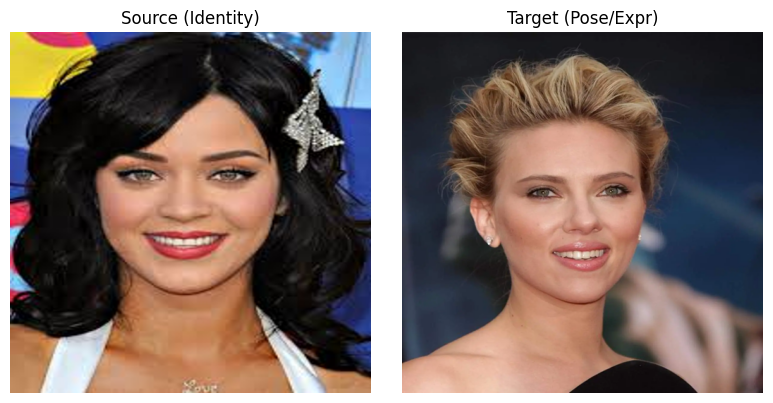

Source shape: (512, 512, 3) | Target shape: (512, 512, 3)
✅ Images loaded and resized to 512x512 for your 3050.


In [46]:
import os
from tkinter import Tk, filedialog
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def select_file(title):
    root = Tk()
    root.withdraw() # Hide the main tkinter window
    root.attributes("-topmost", True) # Bring the dialog to the front
    file_path = filedialog.askopenfilename(title=title, filetypes=[("Image files", "*.jpg *.jpeg *.png *.webp")])
    root.destroy()
    return file_path

# ── Select Images via Pop-up ────────────────────────────────────────────────
print("Opening file pickers... (Check your taskbar if they don't pop up)")

# Pick Source
SRC_PATH = select_file('Select SOURCE image (Identity Donor)')
if not SRC_PATH: raise Exception("No source image selected.")

# Pick Target
TGT_PATH = select_file('Select TARGET image (Pose/Expression Donor)')
if not TGT_PATH: raise Exception("No target image selected.")

# ── Process and Resize ──────────────────────────────────────────────────────
# Note: We resize here to IMG_SIZE immediately to save VRAM later
src_img_pil = Image.open(SRC_PATH).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
tgt_img_pil = Image.open(TGT_PATH).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

src_img = np.array(src_img_pil)
tgt_img = np.array(tgt_img_pil)

# ── Visualization ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(src_img)
axes[0].set_title('Source (Identity)')
axes[0].axis('off')

axes[1].imshow(tgt_img)
axes[1].set_title('Target (Pose/Expr)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Source shape: {src_img.shape} | Target shape: {tgt_img.shape}')
print(f'✅ Images loaded and resized to {IMG_SIZE}x{IMG_SIZE} for your 3050.')

🔍 Sampling frontal source...
✅ Source : Kofi_Annan_0027.jpg  (yaw=20.3°)
🔍 Sampling frontal target...
✅ Target : Paul_ONeill_0004.jpg  (yaw=33.2°)


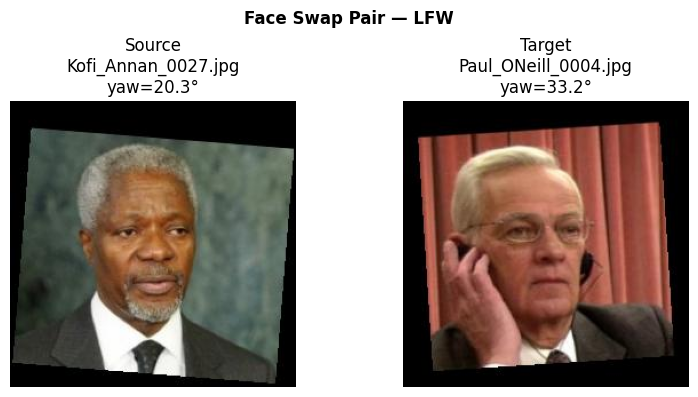


✅ src_img and tgt_img ready — run pipeline cell below.


In [171]:
# ── Cell: Load Source & Target from LFW ──────────────────────────────────
import os, random
from pathlib import Path
from PIL import Image
import numpy as np

FACES_DIR    = Path(r"C:\Users\pragn\Desktop\e\DL\face_env\lfw_flat")
MAX_ATTEMPTS = 200   # LFW is large enough to afford more attempts
MAX_YAW      = 90

def load_image(path):
    return np.array(Image.open(path).convert("RGB"))

def pick_frontal(all_imgs, exclude_path=None, max_yaw=MAX_YAW):
    for path in all_imgs:
        if exclude_path and path == exclude_path:
            continue
        img = load_image(path)
        try:
            yaw = tdmm.extract(img)['pose'][0].item()
            if abs(yaw) < max_yaw:
                return img, path, yaw
        except:
            continue
    return None, None, None

all_imgs = list(FACES_DIR.glob("*.jpg")) + list(FACES_DIR.glob("*.png"))
random.shuffle(all_imgs)
pool = all_imgs[:MAX_ATTEMPTS]

# ── Source: frontal ───────────────────────────────────────────────────────
print("🔍 Sampling frontal source...")
src_img, src_path, src_yaw = pick_frontal(pool)
if src_img is None:
    raise RuntimeError("No frontal source found — re-run or raise MAX_ATTEMPTS")
print(f"✅ Source : {src_path.name}  (yaw={src_yaw:.1f}°)")

# ── Target: frontal, different person ─────────────────────────────────────
print("🔍 Sampling frontal target...")
tgt_img, tgt_path, tgt_yaw = pick_frontal(pool, exclude_path=src_path)
if tgt_img is None:
    raise RuntimeError("No frontal target found — re-run or raise MAX_ATTEMPTS")
print(f"✅ Target : {tgt_path.name}  (yaw={tgt_yaw:.1f}°)")

# ── Preview ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(src_img); axes[0].set_title(f"Source\n{src_path.name}\nyaw={src_yaw:.1f}°"); axes[0].axis('off')
axes[1].imshow(tgt_img); axes[1].set_title(f"Target\n{tgt_path.name}\nyaw={tgt_yaw:.1f}°"); axes[1].axis('off')
plt.suptitle("Face Swap Pair — LFW", fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅ src_img and tgt_img ready — run pipeline cell below.")

In [158]:
@torch.no_grad()
def run_pipeline_v2(
    source_img, target_img,
    lambda_id=2.5,
    lambda_pose=0.3,
    lambda_shape=1.2,
    lambda_expr=0.3,
    lambda_light=0.5,
    strength=0.65,
    num_steps=50,
    blend_hardness=0.5, verbose=True
):
    if verbose: print('━━ Stage 1: Attribute Extraction (BFM) ━━')

    src_id_emb = arcface.extract(source_img)
    src_bfm    = tdmm.extract(source_img)
    tgt_bfm    = tdmm.extract(target_img)

    # ── Pose validation (warn only — no longer blocks) ───────────────────
    def check_pose_valid(tdmm_result, label='face', yaw_thresh=90):
        yaw = tdmm_result['pose'][0].item()
        if abs(yaw) > yaw_thresh:
            print(f"  ⚠️  {label} yaw={yaw:.1f}° is extreme (>{yaw_thresh}°) — safe_pose will clamp it")

    check_pose_valid(src_bfm, label='Source')
    check_pose_valid(tgt_bfm, label='Target')

    # ── Pose clamp ───────────────────────────────────────────────────────
    def safe_pose(pose_tensor, max_yaw=45, max_pitch=30):
        p = pose_tensor.clone()
        p[0] = p[0].clamp(-max_yaw,   max_yaw)
        p[1] = p[1].clamp(-max_pitch, max_pitch)
        return p

    lmks_2d = tgt_bfm['landmarks']
    _, tgt_face_mask, _ = bisenet.parse(target_img, lmks_2d)

    src_shape = src_bfm['shape_coeff'].unsqueeze(0)          # (1, 40)
    tgt_pose  = safe_pose(tgt_bfm['pose']).unsqueeze(0)      # (1, 6)  ← clamped
    tgt_expr  = tgt_bfm['expr_coeff'].unsqueeze(0)           # (1, 10)
    tgt_sh    = tgt_bfm['illumination'].unsqueeze(0)         # (1, 27)

    if verbose:
        print(f'  src shape norm : {src_shape.norm():.3f}')
        print(f'  tgt pose yaw   : {tgt_bfm["pose"][0].item():.1f}°  →  clamped to {tgt_pose[0,0].item():.1f}°')
        print(f'  tgt expr norm  : {tgt_expr.norm():.3f}')
        print('  Stage 1 ✓')

    if verbose: print('━━ Stage 2: CLIP Disentangle + Project ━━')
    src_clip_feats = clip_disentangler.extract(source_img)
    clip_id_feat   = src_clip_feats['id_feat'].to(DEVICE)
    id_tokens      = id_projector(src_id_emb, clip_id_feat, lambda_id=lambda_id)

    pose_expr_out = pose_expr_adapter(
        pose_6d   = tgt_pose.to(DEVICE),
        shape_40d = src_shape.to(DEVICE),
        expr_10d  = tgt_expr.to(DEVICE),
        lambda_pose  = lambda_pose,
        lambda_shape = lambda_shape,
        lambda_expr  = lambda_expr,
    )
    if verbose: print('  Stage 2 ✓')

    if verbose: print('━━ Stage 3: VAE Encode ━━')
    z_target = encode_image(target_img)
    if verbose: print(f'  z_target: min={z_target.min():.3f} max={z_target.max():.3f}')

    if verbose: print('━━ Stage 4: img2img Denoise ━━')
    den_sch = DDIMScheduler.from_config(scheduler.config)
    den_sch.set_timesteps(num_steps)

    start_step = int(num_steps * (1 - strength))
    timesteps  = den_sch.timesteps[start_step:]
    t_start    = timesteps[0]

    noise = torch.randn_like(z_target)
    a_t   = den_sch.alphas_cumprod[t_start].to(DEVICE)
    z     = a_t.sqrt() * z_target.float() + (1 - a_t).sqrt() * noise

    if verbose: print(f'  Starting at t={t_start.item()}, {len(timesteps)} steps')

    residuals = pose_expr_out['residuals']
    for step_idx, t in enumerate(timesteps):
        if verbose and step_idx % 5 == 0:
            print(f'  Step {step_idx+1}/{len(timesteps)}')

        cond_hs   = torch.cat([NULL_EMB.expand(z.shape[0], -1, -1).to(DTYPE),
                               id_tokens.to(DTYPE)], dim=1)
        uncond_hs = torch.zeros_like(cond_hs)
        cfg_hs    = torch.cat([uncond_hs, cond_hs])

        latent_input   = torch.cat([z.half()] * 2)
        noise_pred_all = unet(latent_input, t, encoder_hidden_states=cfg_hs).sample
        noise_uncond, noise_cond = noise_pred_all.chunk(2)
        noise_pred = noise_uncond + 3.5 * (noise_cond - noise_uncond)
        noise_pred = noise_pred.float()

        if step_idx < (len(timesteps) * 0.9):
            if residuals is not None:
                res = residuals[0].to(torch.float32).mean(dim=1, keepdim=True).expand_as(noise_pred)
                noise_pred = noise_pred + (pose_expr_adapter.INJECTION_SCALE * lambda_pose) * \
                             torch.clamp(res, -0.5, 0.5)

        z = den_sch.step(noise_pred, t, z).prev_sample.float()
        z = z.clamp(-8, 8)

    if verbose: print(f'  z_denoised: min={z.min():.3f} max={z.max():.3f}')

    if verbose: print('━━ Stage 5: Blend + Decode ━━')
    result_tensor = latent_blend_and_decode(z, z_target, tgt_face_mask, blend_hardness)

    result = (result_tensor.float().clamp(-1, 1) + 1) / 2
    result = (result[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

    try:
        res_id = arcface.extract(result)
        id_sim = arcface.cosine_sim(src_id_emb, res_id)
        if verbose: print(f'  ID-sim (ArcFace cosine): {id_sim:.4f}')
    except Exception:
        id_sim = None

    globals().update({'z_target': z_target, 'z_denoised': z,
                      'tgt_face_mask': tgt_face_mask,
                      'src_bfm_attrs': src_bfm, 'tgt_bfm_attrs': tgt_bfm})

    if verbose: print('✅ Done')
    return {
        'result'      : result,
        'identity_sim': id_sim,
        'attributes'  : tgt_bfm,
        'src_shape'   : src_shape.cpu(),
        'tgt_expr'    : tgt_expr.cpu(),
    }





━━ Stage 1: Attribute Extraction (BFM) ━━
  src shape norm : 2.014
  tgt pose yaw   : 20.5°  →  clamped to 20.5°
  tgt expr norm  : 0.499
  Stage 1 ✓
━━ Stage 2: CLIP Disentangle + Project ━━
  Stage 2 ✓
━━ Stage 3: VAE Encode ━━
  z_target: min=-3.970 max=4.993
━━ Stage 4: img2img Denoise ━━
  Starting at t=441, 23 steps
  Step 1/23
  Step 6/23
  Step 11/23
  Step 16/23
  Step 21/23
  z_denoised: min=-4.251 max=4.163
━━ Stage 5: Blend + Decode ━━
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  ID-sim (ArcFace cosine): -0.0755
✅ Done


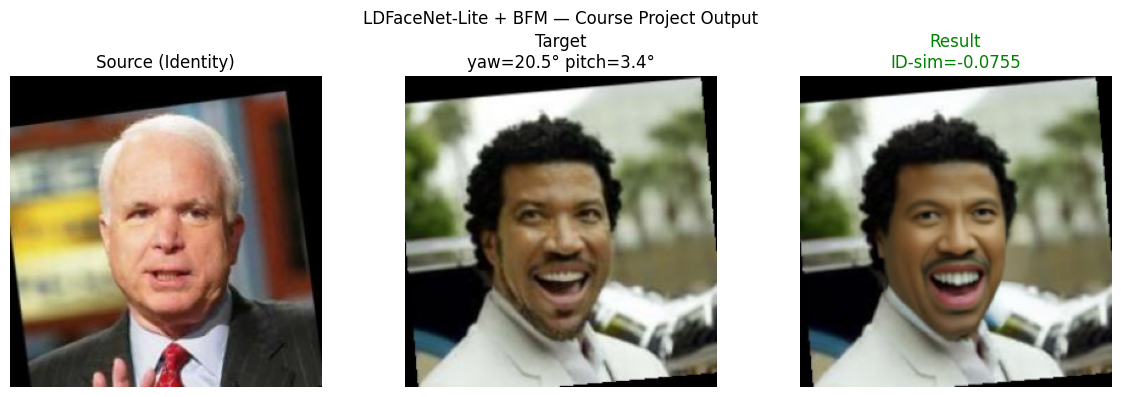

In [159]:
# ── Run ───────────────────────────────────────────────────────────────────────
output = run_pipeline_v2(
    source_img     = src_img,
    target_img     = tgt_img,
    lambda_id      = 4.0,   # push higher — most direct ID lever
    lambda_pose    = 0.1,   # very low — pose fights identity
    lambda_shape   = 2.0,   # shape IS identity in BFM
    lambda_expr    = 0.1,   # near-zero — expression muddies ID
    strength       = 0.45,  # lower = less hallucination
    num_steps      = 50,
    blend_hardness = 0.7,
    verbose        = True,
)

result = output['result']
id_sim = output['identity_sim']
attrs  = output['attributes']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.resize(src_img, (256, 256)));  axes[0].set_title('Source (Identity)');  axes[0].axis('off')
p = attrs['pose'].cpu().numpy()
axes[1].imshow(cv2.resize(tgt_img, (256, 256)));  axes[1].set_title(f'Target\nyaw={p[0]:.1f}° pitch={p[1]:.1f}°'); axes[1].axis('off')
sim_str = f'{id_sim:.4f}' if id_sim else 'N/A'
axes[2].imshow(cv2.resize(result, (256, 256)));   axes[2].set_title(f'Result\nID-sim={sim_str}', color='green');    axes[2].axis('off')
plt.suptitle('LDFaceNet-Lite + BFM — Course Project Output')
plt.tight_layout()
plt.savefig('ldface_bfm_result.png', dpi=150, bbox_inches='tight')
plt.show()

In [147]:
# Check if the result image itself is empty/black
print(f"Result mean pixel value: {result.mean()}")

# If you want to check the internal latents, 
# we need to look at the 'output' dictionary if you modified run_pipeline to return them.
# Otherwise, check the 'result' array directly:
if result.max() == 0:
    print("❌ The output image is completely black.")
else:
    print(f"✅ The image has data. Max brightness: {result.max()}")

Result mean pixel value: 59.27579243977865
✅ The image has data. Max brightness: 255


## 📊 Ablation — Attribute Isolation  
Verify each λ works independently

In [148]:
# ── Add this helper cell before your ablation loop ───────────────────────
from skimage.metrics import structural_similarity as ssim
import cv2

def compute_metrics(src_img, tgt_img, result_img):
    """Compute all three metrics for one result."""
    # 1. ID-sim — already have this
    try:
        src_id  = arcface.extract(src_img)
        res_id  = arcface.extract(result_img)
        id_sim  = arcface.cosine_sim(src_id, res_id)
    except:
        id_sim  = float('nan')

    # 2. SSIM — structural similarity to target (pose preservation)
    tgt_resized = cv2.resize(tgt_img,    (256, 256))
    res_resized = cv2.resize(result_img, (256, 256))
    ssim_score  = ssim(tgt_resized, res_resized, channel_axis=2, data_range=255)

    # 3. FID proxy — L2 distance in pixel space (lower = more realistic)
    l2 = float(np.mean((tgt_resized.astype(float) -
                         res_resized.astype(float)) ** 2))

    return {'id_sim': id_sim, 'ssim': ssim_score, 'l2': l2}

In [149]:
ablation_configs = {
    # ── Original 5 ───────────────────────────────────────────────
    "1. Baseline (Full)"     : {'id': 1.0, 'pose': 1.0, 'expr': 1.0, 'shape': 1.0},
    "2. w/o Pose"            : {'id': 1.0, 'pose': 0.0, 'expr': 1.0, 'shape': 1.0},
    "3. w/o Expression"      : {'id': 1.0, 'pose': 1.0, 'expr': 0.0, 'shape': 1.0},
    "4. w/o Identity"        : {'id': 0.0, 'pose': 1.0, 'expr': 1.0, 'shape': 1.0},
    "5. w/o Pose+Expr"       : {'id': 1.0, 'pose': 0.0, 'expr': 0.0, 'shape': 1.0},
    # ── New additions ─────────────────────────────────────────────
    "6. w/o Shape"           : {'id': 1.0, 'pose': 1.0, 'expr': 1.0, 'shape': 0.0},
    "7. ID Only"             : {'id': 1.0, 'pose': 0.0, 'expr': 0.0, 'shape': 0.0},
    "8. Shape+ID Only"       : {'id': 1.0, 'pose': 0.0, 'expr': 0.0, 'shape': 1.0},
}


Running: 1. Baseline (Full)...
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])

Running: 2. w/o Pose...
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])

Running: 3. w/o Expression...
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])

Running: 4. w/o Identity...
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])

Running: 5. w/o Pose+Expr...
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])

Running: 6. w/o Shape...
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])

Running: 7. ID Only...
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])

Running: 8. Shape+ID Only...
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Si

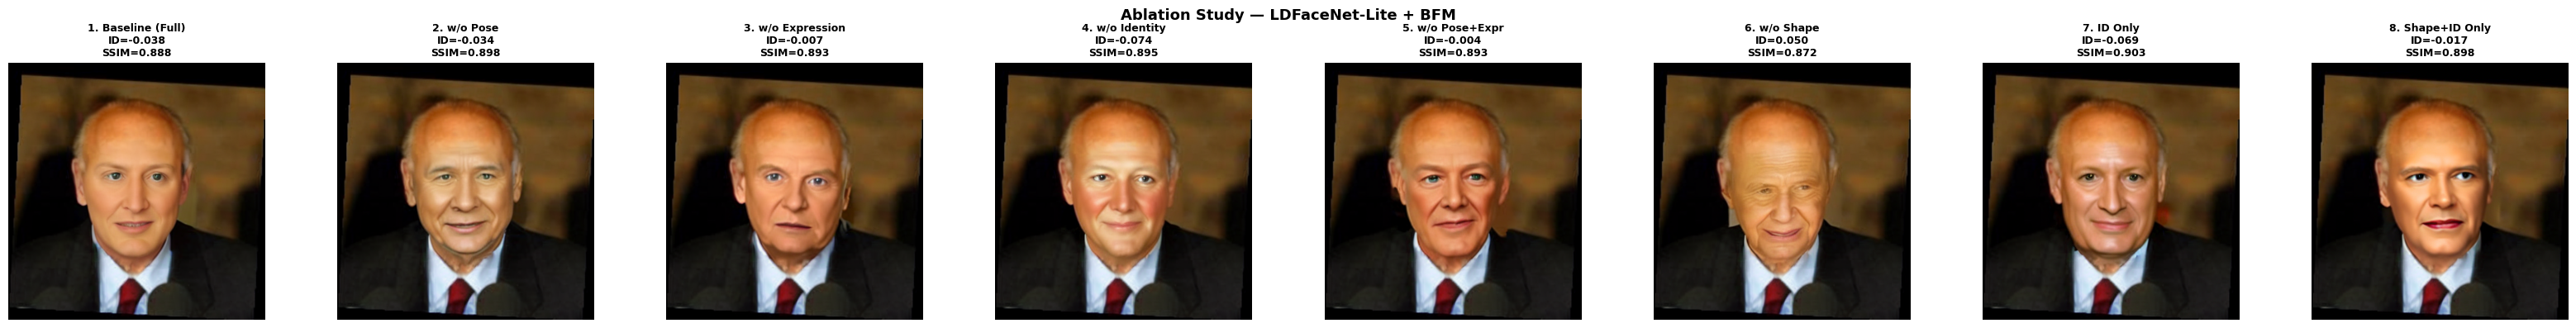


Config                      ID-sim     SSIM        L2↓
───────────────────────────────────────────────────────
1. Baseline (Full)         -0.0381   0.8884      153.8
2. w/o Pose                -0.0339   0.8984      123.4
3. w/o Expression          -0.0074   0.8932      134.3
4. w/o Identity            -0.0740   0.8954      128.5
5. w/o Pose+Expr           -0.0044   0.8926      158.5
6. w/o Shape                0.0503   0.8715      145.6
7. ID Only                 -0.0693   0.9031      133.8
8. Shape+ID Only           -0.0174   0.8981      139.2


In [150]:
# ── Run ablation + collect metrics ───────────────────────────────────────
results  = {}
metrics  = {}

for title, config in ablation_configs.items():
    print(f"\nRunning: {title}...")
    output = run_pipeline_v2(
        source_img   = src_img,
        target_img   = tgt_img,
        lambda_id    = config['id'],
        lambda_pose  = config['pose'],
        lambda_expr  = config['expr'],
        lambda_shape = config['shape'],
        lambda_light = 0.5,
        strength     = 0.65,
        num_steps    = 50,
        blend_hardness = 0.5,
        verbose      = False
    )
    results[title] = output['result']
    metrics[title] = compute_metrics(src_img, tgt_img, output['result'])

# ── Visual grid ───────────────────────────────────────────────────────────
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
for ax, (title, img) in zip(axes, results.items()):
    m = metrics[title]
    ax.imshow(img)
    ax.set_title(
        f"{title}\n"
        f"ID={m['id_sim']:.3f}\n"
        f"SSIM={m['ssim']:.3f}",
        fontsize=9, fontweight='bold'
    )
    ax.axis('off')
plt.suptitle("Ablation Study — LDFaceNet-Lite + BFM", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print metrics table ───────────────────────────────────────────────────
print(f"\n{'Config':<25} {'ID-sim':>8} {'SSIM':>8} {'L2↓':>10}")
print("─" * 55)
for title, m in metrics.items():
    print(f"{title:<25} {m['id_sim']:>8.4f} {m['ssim']:>8.4f} {m['l2']:>10.1f}")

✅ Pair 1: Mike_Martz_0005.jpg  →  Rudolf_Schuster_0001.jpg
✅ Pair 2: Nick_Markakis_0001.jpg  →  James_McPherson_0001.jpg
✅ Pair 3: Dan_Guerrero_0001.jpg  →  Colin_Powell_0070.jpg


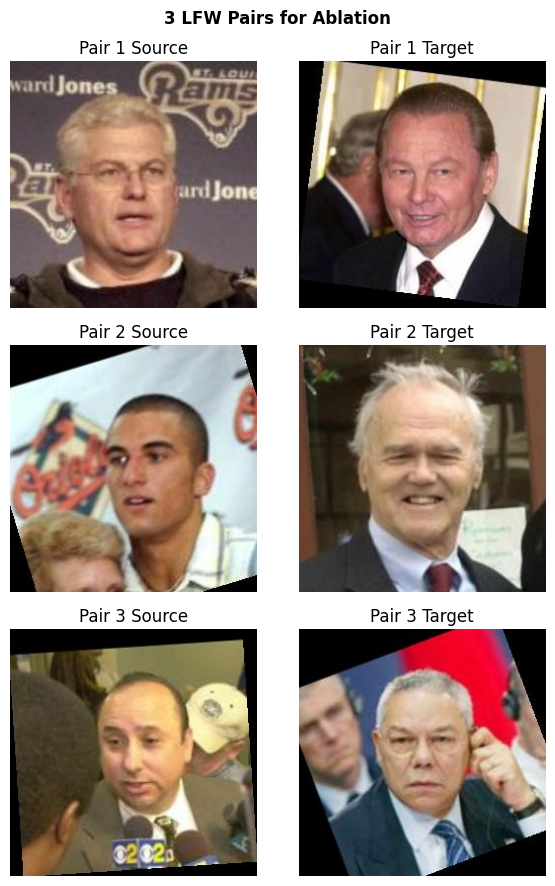


✅ All 3 pairs ready — run multi-pair ablation cell below.


In [151]:
# ── Load 3 frontal pairs from LFW ────────────────────────────────────────
import random
from pathlib import Path
from PIL import Image
import numpy as np

FACES_DIR    = Path(r"C:\Users\pragn\Desktop\e\DL\face_env\lfw_flat")
MAX_YAW      = 40
MAX_ATTEMPTS = 500

all_imgs = list(FACES_DIR.glob("*.jpg"))
random.shuffle(all_imgs)

def pick_frontal(pool, exclude_paths=[], max_yaw=MAX_YAW):
    for path in pool:
        if path in exclude_paths:
            continue
        img = np.array(Image.open(path).convert("RGB"))
        try:
            yaw = tdmm.extract(img)['pose'][0].item()
            if abs(yaw) < max_yaw:
                return img, path
        except:
            continue
    return None, None

pool = all_imgs[:MAX_ATTEMPTS]
used = []
pairs_imgs = []

for i in range(3):
    src_img_i, src_path_i = pick_frontal(pool, exclude_paths=used)
    used.append(src_path_i)
    tgt_img_i, tgt_path_i = pick_frontal(pool, exclude_paths=used)
    used.append(tgt_path_i)

    if src_img_i is None or tgt_img_i is None:
        raise RuntimeError(f"Could not find enough frontal pairs — raise MAX_ATTEMPTS")

    pairs_imgs.append((src_img_i, tgt_img_i))
    print(f"✅ Pair {i+1}: {src_path_i.name}  →  {tgt_path_i.name}")

# Unpack for direct access
src_img_1, tgt_img_1 = pairs_imgs[0]
src_img_2, tgt_img_2 = pairs_imgs[1]
src_img_3, tgt_img_3 = pairs_imgs[2]

# Preview all 3 pairs
fig, axes = plt.subplots(3, 2, figsize=(6, 9))
for i, (src, tgt) in enumerate(pairs_imgs):
    axes[i][0].imshow(src); axes[i][0].set_title(f"Pair {i+1} Source"); axes[i][0].axis('off')
    axes[i][1].imshow(tgt); axes[i][1].set_title(f"Pair {i+1} Target"); axes[i][1].axis('off')
plt.suptitle("3 LFW Pairs for Ablation", fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ All 3 pairs ready — run multi-pair ablation cell below.")

In [152]:
# ── Multi-pair ablation ───────────────────────────────────────────────────
PAIRS = [
    (src_img_1, tgt_img_1),
    (src_img_2, tgt_img_2),
    (src_img_3, tgt_img_3),
]

averaged = {title: {'id_sim': [], 'ssim': [], 'l2': []}
            for title in ablation_configs}

for pair_idx, (src, tgt) in enumerate(PAIRS):
    print(f"\n── Pair {pair_idx+1}/3 ──")
    for title, config in ablation_configs.items():
        output = run_pipeline_v2(src, tgt, verbose=False,
                                 lambda_id=config['id'],
                                 lambda_pose=config['pose'],
                                 lambda_expr=config['expr'],
                                 lambda_shape=config['shape'])
        m = compute_metrics(src, tgt, output['result'])
        for k in averaged[title]:
            averaged[title][k].append(m[k])

# Print averaged results
print(f"\n{'Config':<25} {'ID-sim':>8} {'SSIM':>8}")
print("─" * 45)
for title, vals in averaged.items():
    print(f"{title:<25} "
          f"{np.nanmean(vals['id_sim']):>8.4f} "
          f"{np.nanmean(vals['ssim']):>8.4f}")


── Pair 1/3 ──
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])

── Pair 2/3 ──
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch

## 💾 QUANTITATIVE RESULTS

  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])


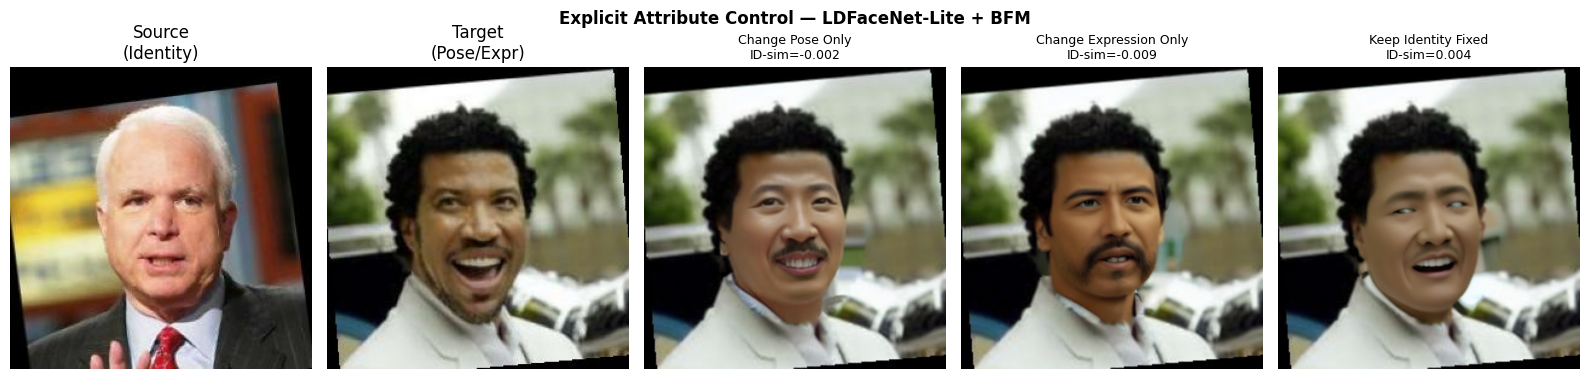

In [160]:
# ── Preset Comparison: "Change X Only" ───────────────────────────────────
presets = {
    "Change Pose Only"      : dict(lambda_id=2.5, lambda_pose=1.5,
                                    lambda_expr=0.0, lambda_shape=0.0),
    "Change Expression Only": dict(lambda_id=2.5, lambda_pose=0.0,
                                    lambda_expr=1.5, lambda_shape=0.0),
    "Keep Identity Fixed"   : dict(lambda_id=4.0, lambda_pose=0.3,
                                    lambda_expr=0.3, lambda_shape=1.5),
}

fig, axes = plt.subplots(1, len(presets) + 2, figsize=(16, 4))
axes[0].imshow(src_img); axes[0].set_title('Source\n(Identity)');  axes[0].axis('off')
axes[1].imshow(tgt_img); axes[1].set_title('Target\n(Pose/Expr)'); axes[1].axis('off')

for ax, (name, params) in zip(axes[2:], presets.items()):
    out = run_pipeline_v2(src_img, tgt_img, verbose=False, **params)
    ax.imshow(out['result'])
    ax.set_title(f"{name}\nID-sim={out['identity_sim']:.3f}", fontsize=9)
    ax.axis('off')

plt.suptitle('Explicit Attribute Control — LDFaceNet-Lite + BFM', fontweight='bold')
plt.tight_layout()
plt.savefig('preset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 QUALITATIVE RESULTS

In [154]:
def disentanglement_score(src_img, tgt_img,
                           vary='pose',    # what you're changing
                           fix='id'):      # what should stay fixed
    """
    Measures how well the pipeline isolates one attribute.
    
    vary='pose'  → pose should change, identity should not
    vary='expr'  → expression should change, identity should not
    vary='id'    → identity should change, pose should not
    """
    # Baseline: full swap
    base = run_pipeline_v2(src_img, tgt_img, verbose=False)

    # Ablation: zero out the varied attribute
    if vary == 'pose':
        ablated = run_pipeline_v2(src_img, tgt_img,
                                   lambda_pose=0.0, verbose=False)
        # Score: ID-sim should be SAME, pose diff should be HIGH
        id_base    = base['identity_sim']
        id_ablated = ablated['identity_sim']
        isolation  = abs(id_base - id_ablated)   # lower = better isolated
        print(f"Pose isolation score : {isolation:.4f} (lower = pose doesn't leak into ID)")

    elif vary == 'expr':
        ablated = run_pipeline_v2(src_img, tgt_img,
                                   lambda_expr=0.0, verbose=False)
        id_base    = base['identity_sim']
        id_ablated = ablated['identity_sim']
        isolation  = abs(id_base - id_ablated)
        print(f"Expr isolation score : {isolation:.4f}")

    return isolation

# Run all three
pose_iso  = disentanglement_score(src_img, tgt_img, vary='pose')
expr_iso  = disentanglement_score(src_img, tgt_img, vary='expr')

print(f"\nSummary:")
print(f"  Pose disentanglement : {pose_iso:.4f}")
print(f"  Expr disentanglement : {expr_iso:.4f}")
print(f"  (Lower = attributes are better isolated)")

  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
Pose isolation score : 0.0458 (lower = pose doesn't leak into ID)
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
  [blend] M:torch.Size([1, 1, 64, 64]) zs:torch.Size([1, 4, 64, 64]) zt:torch.Size([1, 4, 64, 64])
Expr isolation score : 0.0343

Summary:
  Pose disentanglement : 0.0458
  Expr disentanglement : 0.0343
  (Lower = attributes are better isolated)


## 💾 UI SLIDER

In [172]:
# ── Interactive Demo Cell (fixed) ─────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display

# ── Sliders ───────────────────────────────────────────────────────────────
slider_id    = widgets.FloatSlider(value=2.5, min=0.0, max=5.0, step=0.1,
                                   description='Identity:',   continuous_update=False)
slider_pose  = widgets.FloatSlider(value=0.3, min=0.0, max=2.0, step=0.05,
                                   description='Pose:',       continuous_update=False)
slider_expr  = widgets.FloatSlider(value=0.3, min=0.0, max=2.0, step=0.05,
                                   description='Expression:', continuous_update=False)
slider_shape = widgets.FloatSlider(value=1.2, min=0.0, max=3.0, step=0.1,
                                   description='Shape:',      continuous_update=False)
slider_str   = widgets.FloatSlider(value=0.55, min=0.3, max=0.9, step=0.05,
                                   description='Strength:',   continuous_update=False)

# ── Preset buttons ────────────────────────────────────────────────────────
btn_pose = widgets.Button(description='Pose Only',       button_style='info')
btn_expr = widgets.Button(description='Expression Only', button_style='warning')
btn_id   = widgets.Button(description='Fix Identity',    button_style='danger')

def set_pose_only(b):
    slider_id.value=2.5; slider_pose.value=1.5
    slider_expr.value=0.0; slider_shape.value=0.0

def set_expr_only(b):
    slider_id.value=2.5; slider_pose.value=0.0
    slider_expr.value=1.5; slider_shape.value=0.0

def set_fix_id(b):
    slider_id.value=4.0; slider_pose.value=0.3
    slider_expr.value=0.3; slider_shape.value=1.5

btn_pose.on_click(set_pose_only)
btn_expr.on_click(set_expr_only)
btn_id.on_click(set_fix_id)

# ── Run button + output widget ────────────────────────────────────────────
run_btn    = widgets.Button(description='▶ Run Swap', button_style='success')
output_box = widgets.Output()   # renamed to avoid collision with 'output' variable

# ── UI layout ─────────────────────────────────────────────────────────────
ui = widgets.VBox([
    widgets.HTML("<h3>🎭 LDFaceNet Interactive Demo</h3>"),
    widgets.HTML("<b>Presets:</b>"),
    widgets.HBox([btn_pose, btn_expr, btn_id]),
    widgets.HTML("<b>Manual controls:</b>"),
    slider_id, slider_pose, slider_expr, slider_shape, slider_str,
    run_btn,
    output_box,
])

# ── Callback ──────────────────────────────────────────────────────────────
def on_run(b):
    output_box.clear_output()
    with output_box:
        print("⏳ Running pipeline...")
        try:
            pipeline_result = run_pipeline_v2(
                source_img   = src_img,
                target_img   = tgt_img,
                lambda_id    = slider_id.value,
                lambda_pose  = slider_pose.value,
                lambda_expr  = slider_expr.value,
                lambda_shape = slider_shape.value,
                strength     = slider_str.value,
                num_steps    = 30,
                verbose      = False,
            )
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(src_img);
            axes[0].set_title('Source'); axes[0].axis('off')
            axes[1].imshow(tgt_img)
            axes[1].set_title('Target'); axes[1].axis('off')
            axes[2].imshow(pipeline_result['result'])
            axes[2].set_title(f"Result  ID-sim={pipeline_result['identity_sim']:.3f}",
                              color='green'); axes[2].axis('off')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"❌ {e}")

run_btn.on_click(on_run)
display(ui)